### 4.Mini-Project: build a"LOGO brick detector"

Isolating red pixels...
Success! Detected 24 red bricks.


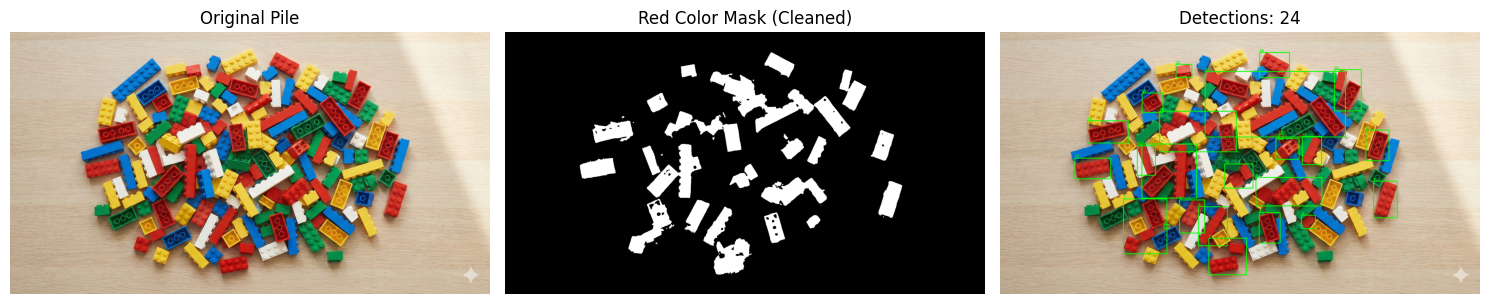

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def detect_all_red_legos(pile_image_path='lego_pile.png'):

    # ---------------------------------------------------------
    # 1. SAFETY CHECKS & LOADING
    # ---------------------------------------------------------
    if not os.path.exists(pile_image_path):
        print(f"ERROR: Cannot find '{pile_image_path}'. Please upload it.")
        return

    # Load image
    img_bgr = cv2.imread(pile_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Convert to HSV (Hue, Saturation, Value) color space
    # HSV is much better for color detection than RGB because it isolates color (Hue) from lighting (Value)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # ---------------------------------------------------------
    # 2. COLOR THRESHOLDING (Finding the Red)
    # ---------------------------------------------------------
    print("Isolating red pixels...")

    # In OpenCV, Hue goes from 0 to 179. Red is tricky because it wraps around the 0 mark.
    # We have to look for red in the lower range (0-10) AND the upper range (160-179).

    # Lower Red Range
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)

    # Upper Red Range
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([179, 255, 255])
    mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

    # Combine both masks to get ALL the red
    red_mask = mask1 + mask2

    # ---------------------------------------------------------
    # 3. CLEANING THE MASK
    # ---------------------------------------------------------
    # Use morphological operations to clean up tiny specks of noise (like a single red pixel on the wood)
    # and fill in small gaps inside the bricks.
    kernel = np.ones((5, 5), np.uint8)
    red_mask_clean = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel) # Removes outside noise
    red_mask_clean = cv2.morphologyEx(red_mask_clean, cv2.MORPH_CLOSE, kernel) # Fills inside holes

    # ---------------------------------------------------------
    # 4. CONTOUR FILTERING & DRAWING
    # ---------------------------------------------------------
    contours, _ = cv2.findContours(red_mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    lego_count = 0
    img_result = img_rgb.copy()

    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Filter out tiny noise (only keep shapes larger than 200 pixels)
        if area > 200:
            lego_count += 1
            x, y, w, h = cv2.boundingRect(cnt)

            # Draw a thick green rectangle
            cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 4)
            # Add a small text label
            cv2.putText(img_result, f'{lego_count}', (x, y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    print(f"Success! Detected {lego_count} red bricks.")

    # ---------------------------------------------------------
    # 5. MATPLOTLIB DISPLAY
    # ---------------------------------------------------------
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Pile")
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Red Color Mask (Cleaned)")
    plt.imshow(red_mask_clean, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Detections: {lego_count}")
    plt.imshow(img_result)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ensure you are passing the correct name of your uploaded pile image
    detect_all_red_legos('lego_pile.png')